# 03 — Ingeniería de Características

Construimos la **matriz de features final** lista para los modelos de ML.

Pipeline:
1. Calcular features endógenas de precio (retornos, medias móviles, volatilidad).
2. Construir la variable objetivo `label` (1=precio sube mañana, 0=baja).
3. Limpiar filas con NaN (warmup de ventanas deslizantes).
4. Guardar la matriz de features en `data/processed/`.

Salidas:
- `data/processed/features_all.csv` → features numéricas + label (todos los mercados)

In [1]:
import sys
from pathlib import Path

ROOT = Path("__file__").resolve().parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RAW_DIR  = ROOT / "data" / "raw"
PROC_DIR = ROOT / "data" / "processed"
PROC_DIR.mkdir(exist_ok=True)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build_market_features, build_labels, temporal_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Cargar datos crudos

In [3]:
price_files = sorted(RAW_DIR.glob("prices_*.csv"))
print(f"Archivos de precios: {len(price_files)}")

price_dfs = {}
for f in price_files:
    slug = f.stem.replace("prices_", "")
    df = pd.read_csv(f, parse_dates=["date"])
    price_dfs[slug] = df

print("Mercados cargados:", list(price_dfs.keys()))

Archivos de precios: 9
Mercados cargados: ['bitboy-convicted', 'us-recession-in-2025', 'will-gta-6-cost-100', 'will-iphone-17-cost-1000-or-more', 'will-iphone-17-cost-1500-or-more', 'will-tariffs-generate-250b-in-2025', 'will-the-us-collect-between-200b-and-500b-in-revenue-in-2025', 'will-the-us-collect-between-500b-and-1t-in-revenue-in-2025', 'will-the-us-collect-less-than-100b-in-revenue-in-2025']


## 2. Features endógenas de precio + labels

In [4]:
MARKET_FEATURE_COLS = ["ret_1d", "ret_3d", "ret_7d", "ma7", "ma14", "ma_ratio", "vol7", "price"]

feat_frames = []

for slug, df in price_dfs.items():
    # 1. Market features
    df_feat = build_market_features(df)

    # 2. Labels
    df_feat = build_labels(df_feat)

    # 3. Attach slug
    df_feat["slug"] = slug

    feat_frames.append(df_feat)

prices_all = pd.concat(feat_frames, ignore_index=True)
print(f"Total filas (todos los mercados, con NaN): {len(prices_all)}")
prices_all[MARKET_FEATURE_COLS + ["label", "slug"]].describe()

Total filas (todos los mercados, con NaN): 2678


,ret_1d,ret_3d,ret_7d,ma7,ma14,ma_ratio,vol7,price,label
count,2669.000000,2651.000000,2615.000000,2660.000000,2642.000000,2642.000000,2651.000000,2678.000000,2678.0
mean,-0.013413,-0.034903,-0.069542,0.182331,0.182938,0.969195,0.188302,0.181694,0.360717
std,0.279008,0.372146,0.474779,0.204761,0.200907,0.152970,0.210334,0.209356,0.480298
min,-2.772582,-2.374043,-3.091023,0.000857,0.001429,0.393901,0.000000,0.000500,0.0
25%,-0.064538,-0.133531,-0.237328,0.025857,0.026768,0.897584,0.055752,0.025000,0.0
50%,0.000000,0.000000,-0.033902,0.094214,0.096179,0.977353,0.109389,0.085000,0.0
75%,0.038100,0.062520,0.097401,0.286429,0.292125,1.032488,0.244979,0.283875,1.0
max,2.252444,2.418834,2.978919,0.972500,0.939750,1.771116,1.548112,0.994000,1.0


## 3. Limpieza: eliminar filas con NaN en features o label

In [5]:
FEATURE_COLS = MARKET_FEATURE_COLS

before = len(prices_all)
data_clean = prices_all.dropna(subset=FEATURE_COLS + ["label"]).reset_index(drop=True)
data_clean["label"] = data_clean["label"].astype(int)

print(f"Filas antes de limpiar  : {before}")
print(f"Filas después de limpiar: {len(data_clean)}")
print(f"Balance de clases:\n{data_clean['label'].value_counts()}")

Filas antes de limpiar  : 2678
Filas después de limpiar: 2615
Balance de clases:
label
0    1661
1     954
Name: count, dtype: int64


In [6]:
SAVE_COLS = ["date", "slug"] + FEATURE_COLS + ["label"]
data_clean[SAVE_COLS].to_csv(PROC_DIR / "features_all.csv", index=False)
print(f"Dataset guardado en data/processed/features_all.csv")
print(f"Shape: {data_clean[SAVE_COLS].shape}")
data_clean[SAVE_COLS].head()

Dataset guardado en data/processed/features_all.csv
Shape: (2615, 11)


,date,slug,ret_1d,ret_3d,ret_7d,ma7,ma14,ma_ratio,vol7,price,label
0,2025-04-03 00:00:00+00:00,bitboy-convicted,0.529259,0.529259,0.196115,0.247857,0.254375,0.974377,0.234573,0.365,0
1,2025-04-04 00:00:00+00:00,bitboy-convicted,0.000000,0.529259,0.358634,0.263571,0.266667,0.988393,0.220172,0.365,1
2,2025-04-05 00:00:00+00:00,bitboy-convicted,0.284252,0.813511,0.642885,0.296429,0.288500,1.027482,0.234870,0.485,1
3,2025-04-06 00:00:00+00:00,bitboy-convicted,0.010256,0.294508,0.823767,0.335714,0.306818,1.094180,0.209793,0.490,1
4,2025-04-07 00:00:00+00:00,bitboy-convicted,0.010152,0.304660,0.833920,0.375714,0.322500,1.165006,0.208877,0.495,1


## 4. Correlación entre features

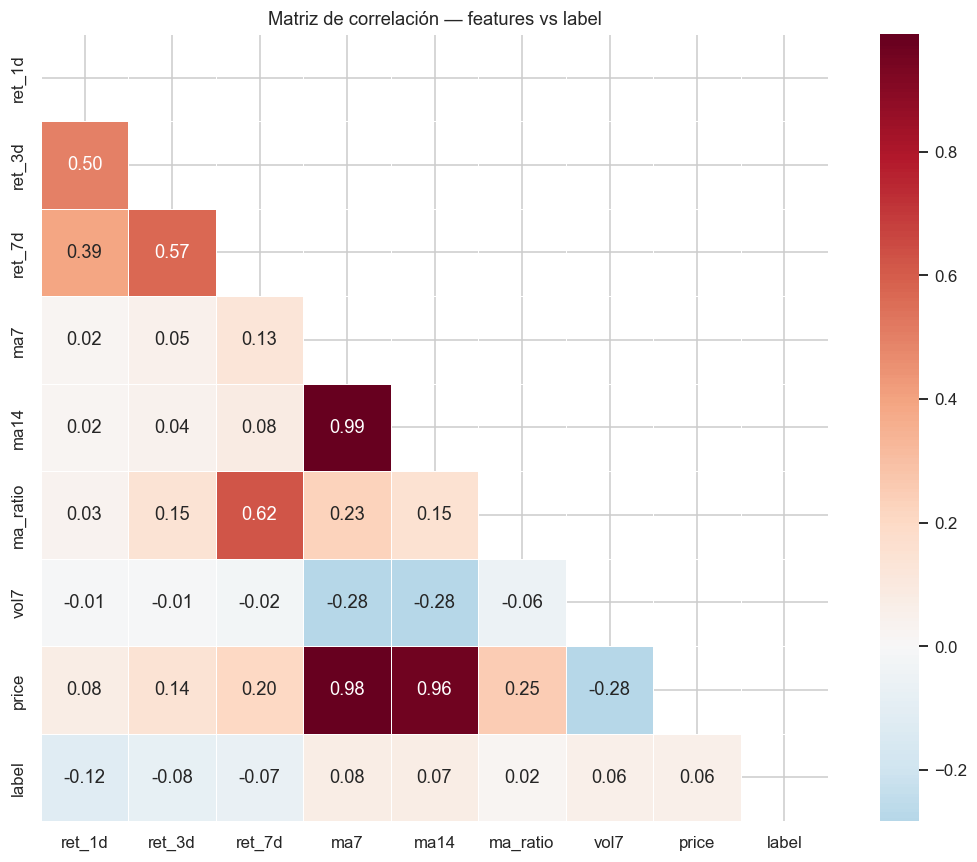

In [7]:
corr = data_clean[FEATURE_COLS + ["label"]].corr()

plt.figure(figsize=(10, 8))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True,
)
plt.title("Matriz de correlación — features vs label")
plt.tight_layout()
plt.savefig(PROC_DIR / "correlation_matrix.png", bbox_inches="tight")
plt.show()

## 5. Verificación del split temporal

In [8]:
train, test = temporal_split(data_clean, train_ratio=0.70)

print(f"Train: {len(train)} filas  | {train['date'].min()} → {train['date'].max()}")
print(f"Test : {len(test)}  filas  | {test['date'].min()} → {test['date'].max()}")
print(f"\nBalance de clases en train:\n{train['label'].value_counts()}")
print(f"\nBalance de clases en test:\n{test['label'].value_counts()}")

Train: 1830 filas  | 2025-01-16 00:00:00+00:00 → 2025-11-04 00:00:00+00:00
Test : 785  filas  | 2025-11-04 00:00:00+00:00 → 2026-04-01 00:00:00+00:00

Balance de clases en train:
label
0    1211
1     619
Name: count, dtype: int64

Balance de clases en test:
label
0    450
1    335
Name: count, dtype: int64
